# Data loading

In [1]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [2]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 69.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=3bbb070b69cdb4be3a81aa6911a28261905eb6177b46686a6a09fad8d13f5703
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [3]:
import re
import glob

import numpy as np
import pandas as pd

import japanize_matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [4]:
# Google Drive path (for Colab)
data_path = "/content/drive/MyDrive/Data/2_tourism-demand-forecast-japan/data/"
images_path = "/content/drive/MyDrive/Data/2_tourism-demand-forecast-japan/images/"

df = pd.read_csv(data_path + "japan_inbound_visitors_monthly.csv")

print(df.shape)
df.head()

(51876, 5)


,Country/Area,Month (abbr),Year,Visitor Arrivals,Growth Rate(%)
0,Afghanistan,Jan.,2012,204,-93.525864805
1,Afghanistan,Feb.,2012,152,-95.490952240
2,Afghanistan,Mar.,2012,131,-95.931677019
3,Afghanistan,Apr.,2012,141,-96.276736203
4,Afghanistan,May,2012,150,-94.309559939


# Monthly number of foreign visitors to Japan (1990–2025)

In [5]:
# 月データを作る
df["Month"] = df["Month (abbr)"] + " " + df["Year"].astype(str)

# ピリオドを削除
df["Month"] = df["Month"].str.replace(".", "", regex=False)

# datetime型に変換
df["Month"] = pd.to_datetime(df["Month"], format="%b %Y")

df.head()

,Country/Area,Month (abbr),Year,Visitor Arrivals,Growth Rate(%),Month
0,Afghanistan,Jan.,2012,204,-93.525864805,2012-01-01
1,Afghanistan,Feb.,2012,152,-95.490952240,2012-02-01
2,Afghanistan,Mar.,2012,131,-95.931677019,2012-03-01
3,Afghanistan,Apr.,2012,141,-96.276736203,2012-04-01
4,Afghanistan,May,2012,150,-94.309559939,2012-05-01


In [6]:
# 欠損値は、ある国からの到着者数がゼロだった月を表す
# したがって、NaN値は0に置き換えます。

df["Visitor Arrivals"] = (
    df["Visitor Arrivals"]
    .astype(str)
    .str.replace(",", "")
    .replace("nan", "0")
    .astype(int)  # int型に変換
)

In [7]:
# 月ごとの訪日客総数を作る
monthly_total = df.groupby("Month")["Visitor Arrivals"].sum()

# DataFrameに戻す
monthly_total = monthly_total.reset_index()

monthly_total.tail()

,Month,Visitor Arrivals
427,2025-08-01,3428406
428,2025-09-01,3267228
429,2025-10-01,3896524
430,2025-11-01,3518195
431,2025-12-01,3617791


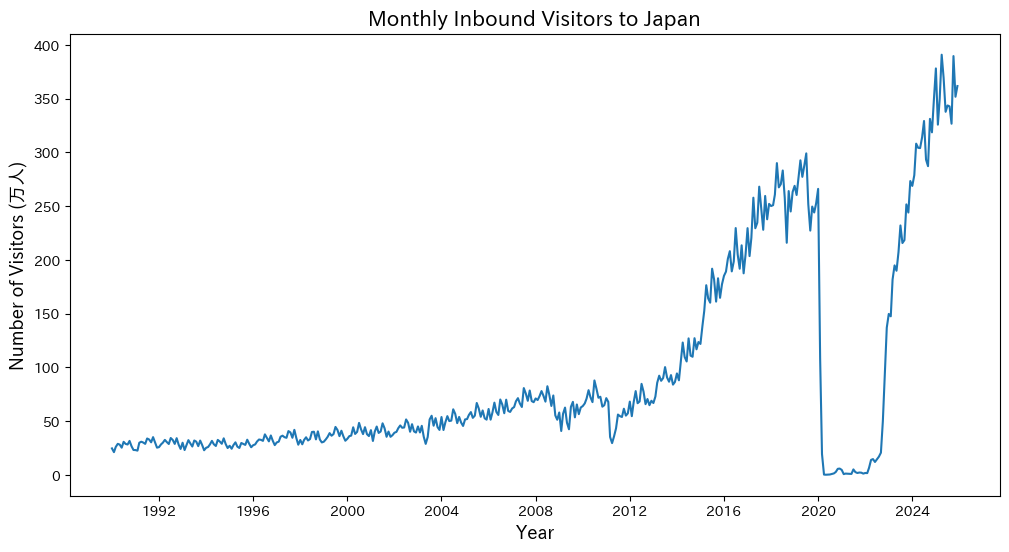

In [8]:
# visualization
plt.figure(figsize=(12,6))

plt.plot(monthly_total["Month"], monthly_total["Visitor Arrivals"])

plt.title("Monthly Inbound Visitors to Japan", fontsize=15)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Number of Visitors (万人)", fontsize=13)

# 万人単位で表示
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}')
)

plt.savefig(images_path + "monthly_inbound_visitors.png", dpi=300)
plt.show()

# Seasonality analysis

In [9]:
# 季節性分析

# month列を作成
monthly_total["month"] = monthly_total["Month"].dt.month
monthly_total["year"] = monthly_total["Month"].dt.year

# 1990–2025の月別平均
seasonality_all = (
    monthly_total
    .groupby("month")["Visitor Arrivals"]
    .mean()
    / 10000
)

# 2023–2025の月別平均
seasonality_recent = (
    monthly_total[monthly_total["year"].between(2023, 2025)]
    .groupby("month")["Visitor Arrivals"]
    .mean()
    / 10000
)

display(seasonality_all.head(3))
display(seasonality_recent.head(3))

,Visitor Arrivals
month,
1,91.229728
2,83.004006
3,88.146664


,Visitor Arrivals
month,
1,265.585967
2,250.739000
3,279.905067


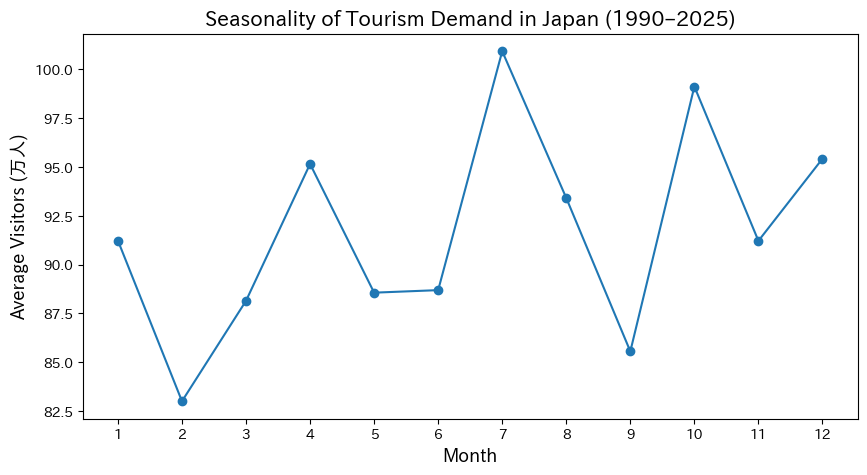

In [10]:
# visualization
plt.figure(figsize=(10,5))
plt.plot(seasonality_all.index, seasonality_all.values, marker="o")

plt.title("Seasonality of Tourism Demand in Japan (1990–2025)", fontsize=15)
plt.xlabel("Month", fontsize=13)
plt.ylabel("Average Visitors (万人)", fontsize=13)

plt.xticks(range(1,13))

plt.savefig(images_path + "seasonality_of_tourism_demand(1990–2025).png", dpi=300)

plt.show()

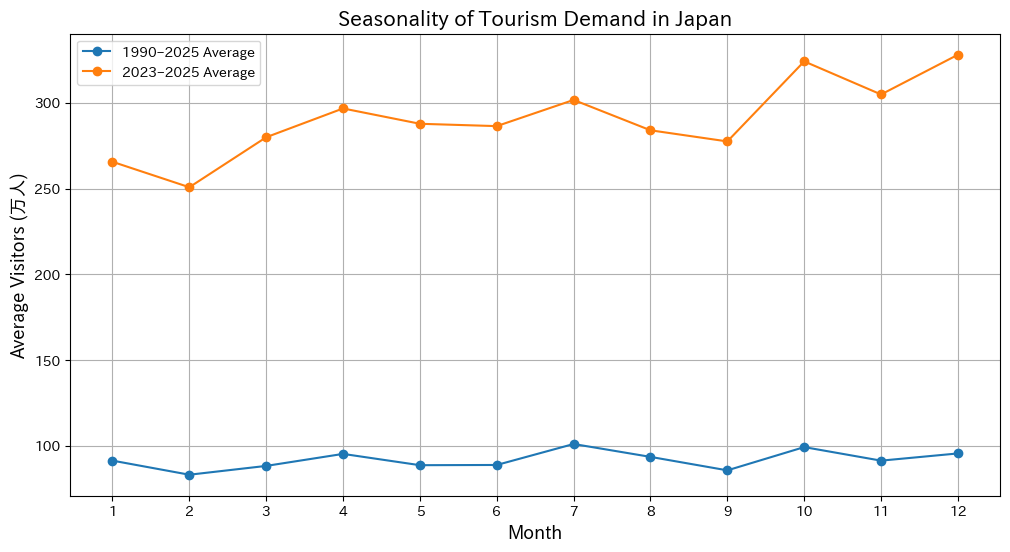

In [11]:
# 可視化
plt.figure(figsize=(12,6))

plt.plot(
    seasonality_all.index,
    seasonality_all.values,
    marker="o",
    label="1990–2025 Average"
)

plt.plot(
    seasonality_recent.index,
    seasonality_recent.values,
    marker="o",
    label="2023–2025 Average"
)

plt.title("Seasonality of Tourism Demand in Japan", fontsize=15)
plt.xlabel("Month", fontsize=13)
plt.ylabel("Average Visitors (万人)", fontsize=13)
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.savefig(images_path + "seasonality_of_tourism_demand.png", dpi=300)

plt.show()

# Exchange rate data acquisition

In [12]:
# USD/JPY daily data from FRED of St. Louis
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXJPUS"

exchange = pd.read_csv(url)

# Date conversion
exchange["observation_date"] = pd.to_datetime(exchange["observation_date"])

# Monthly average exchange rate
exchange_monthly = (
    exchange
    .set_index("observation_date")
    .resample("MS")["DEXJPUS"]
    .mean()
    .reset_index()
    .rename(columns={"observation_date": "Month", "DEXJPUS": "usd_jpy"})
)

display(exchange.head(3))
display(exchange_monthly.head(3))

,observation_date,DEXJPUS
0,1971-01-04,357.73
1,1971-01-05,357.81
2,1971-01-06,357.86


,Month,usd_jpy
0,1971-01-01,358.020000
1,1971-02-01,357.545000
2,1971-03-01,357.518696


# Merge "Inbound Tourist Data" and "Exchange Rate Data"

In [13]:
# Merge
data = pd.merge(
    monthly_total,
    exchange_monthly,
    on="Month",
    how="left"
)

print(data.shape)
data.head()

(432, 5)


,Month,Visitor Arrivals,month,year,usd_jpy
0,1990-01-01,246690,1,1990,144.981905
1,1990-02-01,211618,2,1990,145.693158
2,1990-03-01,260054,3,1990,153.308182
3,1990-04-01,288976,4,1990,158.458571
4,1990-05-01,281982,5,1990,154.044091


In [14]:
# 相関関係
data[["Month","Visitor Arrivals","usd_jpy"]].corr()

,Month,Visitor Arrivals,usd_jpy
Month,1.000000,0.664285,0.042964
Visitor Arrivals,0.664285,1.000000,0.325320
usd_jpy,0.042964,0.325320,1.000000


####`訪日外客数`と`為替（usd_jpy）`の相関係数は`約0.33`

これは「弱い正の相関」を示しており、

円安（usd_jpyが上昇）になると訪日外客数が増える傾向はある。

ただし、その関係は強いとは言えない。

---
####`Month`と`訪日外客数`の相関が`約0.66`

これは時間の経過（長期トレンド）とともに訪日外客数が増加していることを反映している。（因果関係というより、トレンドの影響）

---
####`Month`と`usd_jpy`の相関はほぼゼロ（約0.04）

為替自体は長期的に一方向に動いているわけではない。

---
####まとめ

- 訪日外客数は長期的には増加トレンドが強い。
- 為替はその補助的な要因として影響している可能性があるが、
相関だけを見る限りでは、為替単独で説明できるほど強い関係ではない。

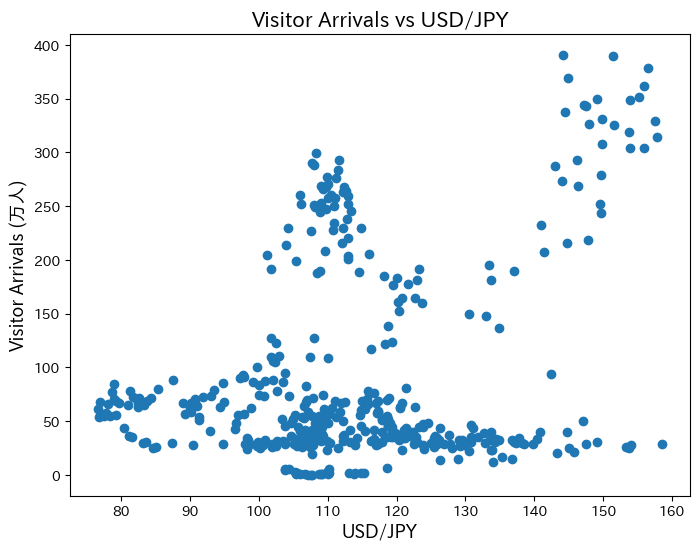

In [15]:
# visualization
plt.figure(figsize=(8,6))
plt.scatter(data["usd_jpy"], data["Visitor Arrivals"])
plt.xlabel("USD/JPY", fontsize=13)
plt.ylabel("Visitor Arrivals (万人)", fontsize=13)
plt.title("Visitor Arrivals vs USD/JPY", fontsize=15)

# 万人単位で表示
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}')
)

plt.show()

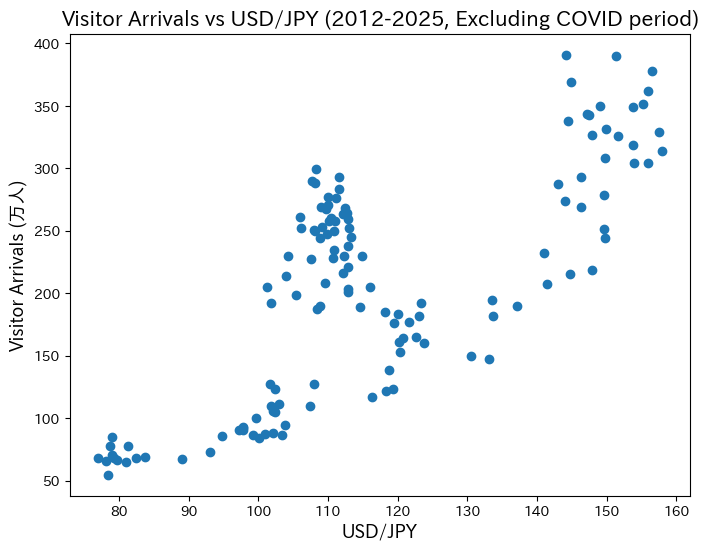

In [16]:
# 2012年以降にフィルタ + コロナ期を外す
data_clean = data[
    (data["Month"] >= "2012-01-01") &
    (data["Month"] < "2020-01-01") |
    (data["Month"] >= "2023-01-01")
]

# scatter plot
plt.figure(figsize=(8,6))
plt.scatter(data_clean["usd_jpy"], data_clean["Visitor Arrivals"])
plt.title("Visitor Arrivals vs USD/JPY (2012-2025, Excluding COVID period)", fontsize=15)
plt.xlabel("USD/JPY", fontsize=13)
plt.ylabel("Visitor Arrivals (万人)", fontsize=13)

# 万人単位で表示
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}')
)

plt.savefig(images_path + "exchange_rate(2012-2025).png", dpi=300)

plt.show()

# REER (Real Effective Exchange Rate)

In [18]:
# 1964-01 から 2026-03 まで
reer = pd.read_csv(data_path + "BIS_REER_Japan.csv", skiprows=9)

# 列名を整理
reer.columns = ["date", "reer"]

# date列を日付変換。変換できない行はNaTにする
reer["date"] = pd.to_datetime(reer["date"], errors="coerce")

# reer列を数値変換
reer["reer"] = pd.to_numeric(reer["reer"], errors="coerce")

# 日付・数値に変換できなかった行を削除
reer = reer.dropna(subset=["date", "reer"])

display(reer.head())
display(reer.tail())

/tmp/ipykernel_942/1616595352.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reer["date"] = pd.to_datetime(reer["date"], errors="coerce")


,date,reer
2,1964-01-31,57.07
3,1964-02-29,56.63
4,1964-03-31,56.62
5,1964-04-30,57.16
6,1964-05-31,60.33


,date,reer
744,2025-11-30,65.58
745,2025-12-31,64.69
746,2026-01-31,64.12
747,2026-02-28,63.73
748,2026-03-31,63.12


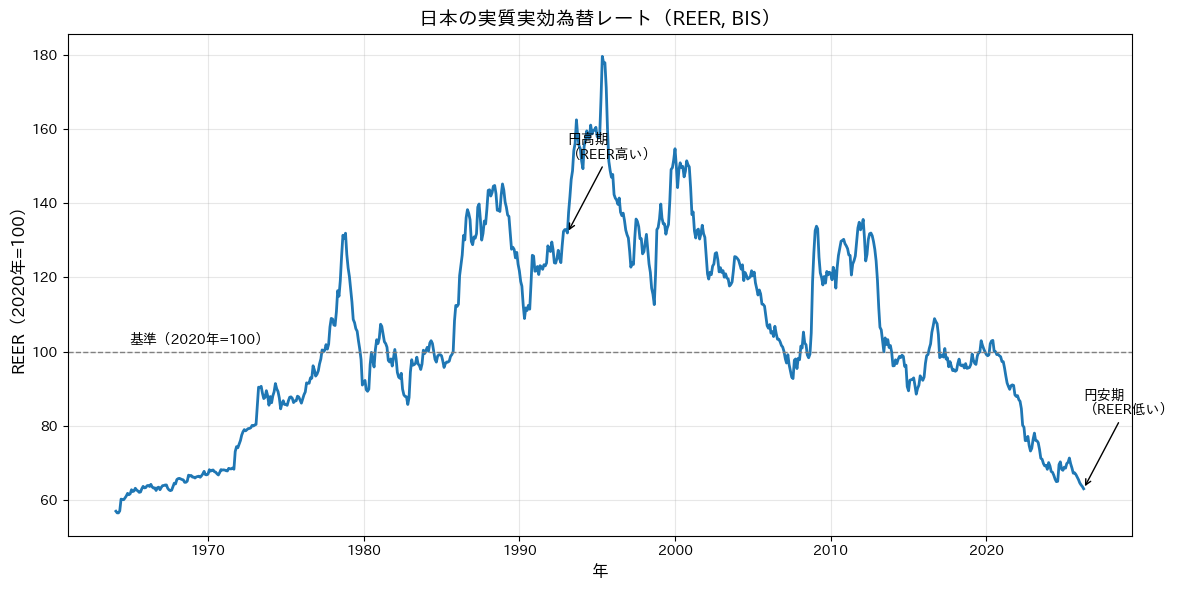

In [19]:
# visualization
plt.figure(figsize=(12, 6))

plt.plot(reer["date"], reer["reer"], linewidth=2)

# タイトル（日本語＋英語）
plt.title("日本の実質実効為替レート（REER, BIS）", fontsize=14)

# 軸ラベル
plt.xlabel("年", fontsize=12)
plt.ylabel("REER（2020年=100）", fontsize=12)

# グリッド
plt.grid(True, alpha=0.3)

# 基準ライン（100）
plt.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.text(reer["date"].iloc[10], 102, "基準（2020年=100）", fontsize=10)

# 注釈（ざっくり重要ポイント）
plt.annotate("円高期\n（REER高い）",
             xy=(reer["date"][350], reer["reer"][350]),
             xytext=(reer["date"][350], reer["reer"][350]+20),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("円安期\n（REER低い）",
             xy=(reer["date"].iloc[-1], reer["reer"].iloc[-1]),
             xytext=(reer["date"].iloc[-1], reer["reer"].iloc[-1]+20),
             arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.savefig(images_path + "japan_reer.png", dpi=300)
plt.show()

# Google Trends

In [20]:
trends = pd.read_csv(data_path + "google_trends.csv")

# time型
trends["Time"] = pd.to_datetime(trends["Time"])

print(trends.shape)
display(trends.head(3))
display(trends.tail(3))
trends.dtypes

(268, 6)


,Time,Japan Travel,France Travel,Spain Travel,America Travel,World Travel
0,2004-01-01,16,21,20,24,66
1,2004-02-01,17,19,18,21,55
2,2004-03-01,16,21,17,22,57


,Time,Japan Travel,France Travel,Spain Travel,America Travel,World Travel
265,2026-02-01,77,61,35,22,86
266,2026-03-01,62,52,29,20,78
267,2026-04-01,37,26,15,14,56


,0
Time,datetime64[ns]
Japan Travel,int64
France Travel,int64
Spain Travel,int64
America Travel,int64
World Travel,int64


# 宿泊旅行統計データ抽出（月次、2007-2025年）

In [21]:
files = glob.glob("/content/drive/MyDrive/Data/2_tourism-demand-forecast-japan/data/excel/*.xlsx")

all_rows = []

for f in files:
    year = int(re.search(r"\d{4}", f).group())

    xls = pd.ExcelFile(f)
    sheets = [
        s for s in xls.sheet_names
        if "第2表" in s and "月" in s and "参考" not in s and "年計" not in s
    ]

    for sheet in sheets:
        tmp = pd.read_excel(f, sheet_name=sheet, header=None)

        hit = tmp[tmp.iloc[:, 0].astype(str).str.contains("令和|平成", na=False)]

        if hit.empty:
            print("no hit:", f, sheet)
            continue

        total_row = hit.iloc[0]
        m = re.search(r"(\d+)月", str(sheet))
        if m:
            month = int(m.group(1))
        else:
            print("NG:", year, sheet)
            continue

        total = total_row.iloc[1]
        foreign = total_row.iloc[-1]

        # --- append ---
        all_rows.append({
            "year": year,
            "Month": month,
            "total_guest_nights": total,
            "foreign_guest_nights": foreign
        })

df_lodging = (
    pd.DataFrame(all_rows)
    .sort_values(["year", "Month"])
    .reset_index(drop=True)
)

df_lodging["Month"] = df_lodging["Month"].astype(str).str.extract(r"(\d+)").astype(int)

df_lodging["Month"] = pd.to_datetime(
    df_lodging["year"].astype(str) + "-" + df_lodging["Month"].astype(str) + "-01"
)

print(df_lodging.shape)
display(df_lodging.head())
df_lodging.tail()

(228, 4)


,year,Month,total_guest_nights,foreign_guest_nights
0,2007,2007-01-01,22136270,717180
1,2007,2007-02-01,23346870,829480
2,2007,2007-03-01,26997200,944300
3,2007,2007-04-01,23729790,1076900
4,2007,2007-05-01,25636730,933660


,year,Month,total_guest_nights,foreign_guest_nights
223,2025,2025-08-01,65984780,3812830
224,2025,2025-09-01,53104940,3692020
225,2025,2025-10-01,58610530,4899270
226,2025,2025-11-01,55990380,4382470
227,2025,2025-12-01,53593590,4455100


#　データ統合

In [22]:
# 1990年から2025年の月毎の訪日外客数データ
visitors = df.groupby("Month")["Visitor Arrivals"].sum()

# DataFrameに変換
visitors = visitors.to_frame(name="visitors").reset_index()

# 前処理
reer["Month"] = pd.to_datetime(reer["date"]).dt.to_period("M").dt.to_timestamp()
trends["Month"] = pd.to_datetime(trends["Time"])

# 結合
df_model = df_lodging.merge(visitors, on="Month", how="inner")
df_model = df_model.merge(reer, on="Month", how="inner")
df_model = df_model.merge(trends, on="Month", how="inner")

# 不要列除去
df_model = df_model.drop(columns=["date", "Time"])
df_model = df_model.drop(columns=[
    "France Travel",
    "Spain Travel",
    "America Travel"
])

df_model = df_model.set_index("Month")

df_model["foreign_guest_nights"] = pd.to_numeric(
    df_model["foreign_guest_nights"], errors="coerce"
)

print(visitors.shape, reer.shape, trends.shape, df_model.shape)

display(df_model.head())
display(df_model.tail())

# 各月の訪日客数（目的変数）
# 各月のREER
# 各月の検索需要

(432, 2) (747, 3) (268, 7) (228, 7)


,year,total_guest_nights,foreign_guest_nights,visitors,reer,Japan Travel,World Travel
Month,,,,,,,
2007-01-01,2007,22136270,717180.0,617885,98.10,10,43
2007-02-01,2007,23346870,829480.0,631278,96.97,9,35
2007-03-01,2007,26997200,944300.0,684654,99.21,10,41
2007-04-01,2007,23729790,1076900.0,714014,96.52,9,34
2007-05-01,2007,25636730,933660.0,664489,94.88,10,39


,year,total_guest_nights,foreign_guest_nights,visitors,reer,Japan Travel,World Travel
Month,,,,,,,
2025-08-01,2025,65984780,3812830.0,3428406,67.41,56,55
2025-09-01,2025,53104940,3692020.0,3267228,66.96,62,60
2025-10-01,2025,58610530,4899270.0,3896524,66.25,67,56
2025-11-01,2025,55990380,4382470.0,3518195,65.58,89,74
2025-12-01,2025,53593590,4455100.0,3617791,64.69,100,81


In [23]:
# 相関を確認
display(df_model["visitors"].corr(df_model["Japan Travel"].shift(1)))
display(df_model["visitors"].corr(df_model["Japan Travel"].shift(2)))
display(df_model["visitors"].corr(df_model["Japan Travel"].shift(3)))
print()
display(df_model["visitors"].corr(df_model["reer"].shift(1)))
display(df_model["visitors"].corr(df_model["reer"].shift(2)))
display(df_model["visitors"].corr(df_model["reer"].shift(3)))
print()
display(df_model["visitors"].corr(df_model["total_guest_nights"]))
display(df_model["visitors"].corr(df_model["foreign_guest_nights"]))

np.float64(0.33962793544429615)

np.float64(0.33539727590410573)

np.float64(0.315934719476044)

np.float64(-0.550251266676234)

np.float64(-0.5589243919403071)

np.float64(-0.5688370415243624)

np.float64(0.7947545583626786)

np.float64(0.9657728593055426)

In [43]:
# ラグ作成
df_model["visitors_lag1"]  = df_model["visitors"].shift(1)
df_model["visitors_lag12"] = df_model["visitors"].shift(12)

df_model["jt_lag1"] = df_model["Japan Travel"].shift(1)
df_model["jt_lag2"] = df_model["Japan Travel"].shift(2)

df_model["wt_lag1"] = df_model["World Travel"].shift(1)
df_model["wt_lag2"] = df_model["World Travel"].shift(2)

df_model["reer_lag1"] = df_model["reer"].shift(1)
df_model["reer_lag2"] = df_model["reer"].shift(2)

df_model["total_lag1"]   = df_model["total_guest_nights"].shift(1)
df_model["total_lag2"]   = df_model["total_guest_nights"].shift(2)
df_model["foreign_lag1"] = df_model["foreign_guest_nights"].shift(1)
df_model["foreign_lag2"] = df_model["foreign_guest_nights"].shift(2)

# dropna後のデータを別名にする
df_sarimax = df_model.dropna().copy()

# 目的変数と説明変数をここで作る
y = df_sarimax["visitors"]

X = df_sarimax[
    [
        "visitors_lag1",
        "visitors_lag12",
        "jt_lag1",
        "jt_lag2",
        "wt_lag1",
        "wt_lag2",
        "reer_lag1",
        "reer_lag2",
        "total_lag1",
        "total_lag2",
        "foreign_lag1",
        "foreign_lag2",
    ]
]

# SARIMAX

In [44]:
# SARIMAXモデル
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y,
    exog=X,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

# モデル学習
results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python

                                     SARIMAX Results                                      
Dep. Variable:                           visitors   No. Observations:                  211
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2682.889
Date:                            Wed, 29 Apr 2026   AIC                           5399.778
Time:                                    06:22:31   BIC                           5455.679
Sample:                                         0   HQIC                          5422.405
                                            - 211                                         
Covariance Type:                              opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
visitors_lag1     -0.4647      0.223     -2.084      0.037      -0.902      -0.028
visitors_lag12     0.03

In [45]:
# y と X の index が完全に一致しているか確認
print(y.index.equals(X.index))
print(y.shape, X.shape)

True
(211,) (211, 12)


In [46]:
# 予測
pred = results.predict(
    start=y.index[0],
    end=y.index[-1],
    exog=X
)

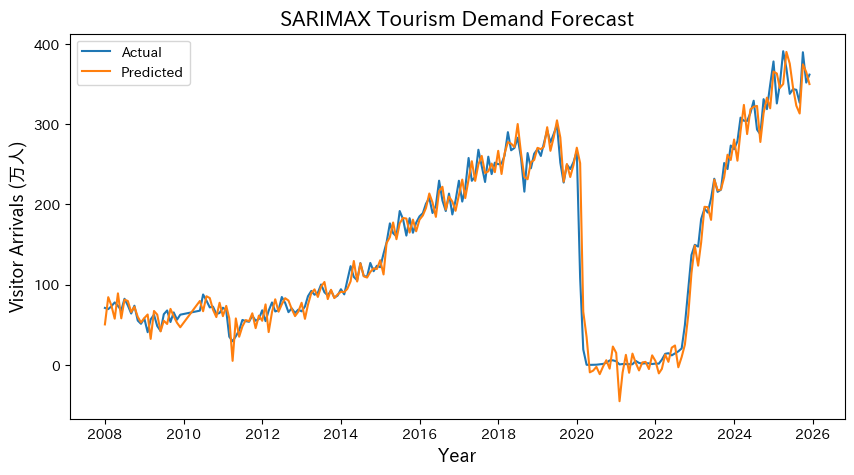

In [47]:
# 可視化
plt.figure(figsize=(10,5))

plt.plot(y, label="Actual")
plt.plot(pred, label="Predicted")

plt.legend()
plt.title("SARIMAX Tourism Demand Forecast", fontsize=15)

plt.xlabel("Year", fontsize=13)
plt.ylabel("Visitor Arrivals (万人)", fontsize=13)

# 万人単位で表示
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}')
)

plt.savefig(images_path + "tourism_demand_forecast.png", dpi=300)

plt.show()

In [49]:
# 予測精度
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
mape = np.mean(np.abs((y - pred) / y)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print((y < 10000).sum())

MAE: 121469.67769275598
RMSE: 177319.43616513998
MAPE: 187.18388889333306
7


# 未来予測（Forecasting）

In [50]:
future_exog = X.iloc[-1:].values # 2025年12月時点のラグ情報（＝2026年1月用のX）1行だけ取り出す

# 予測
forecast = results.get_forecast(
    steps=1,
    exog=future_exog
)

pred_2026_01 = forecast.predicted_mean.iloc[0]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [87]:
# 2026年1月実測値
df_2026 = pd.read_csv("/content/drive/MyDrive/Data/2_tourism-demand-forecast-japan/data/2026visitors.csv")

# 月データを作る
df_2026["Month"] = df_2026["Month (abbr)"] + " " + df_2026["Year"].astype(str)

# ピリオドを削除
df_2026["Month"] = df_2026["Month"].str.replace(".", "", regex=False)

# datetime型に変換
df_2026["Month"] = pd.to_datetime(df_2026["Month"], format="%b %Y")

df_2026["Visitor Arrivals"] = (
    df_2026["Visitor Arrivals"]
    .astype(str)
    .str.replace(",", "")
    .replace("nan", "0")
    .astype(int)  # int型に変換
)

# 2026年1月の訪日外客数データ
actual_2026_01 = df_2026.groupby("Month")["Visitor Arrivals"].sum()

# 数値を取り出す
actual = actual_2026_01.to_frame(name="visitors").values.item()

actual

3597881

In [97]:
# 推測値と実測値の比較
pred = float(pred_2026_01)

# 計算
error = pred - actual
abs_error = abs(error)
ape = abs_error / actual * 100

# 表示
print(f"pred visitors : {pred:,.0f}")
print(f"actual visitors : {actual:,.0f}")
print(f"error : {error:,.0f}")
print(f"abs error : {abs_error:,.0f}")
print(f"APE (%) : {ape:.2f}")

pred visitors : 3,853,925
actual visitors : 3,597,881
error : 256,044
abs error : 256,044
APE (%) : 7.12


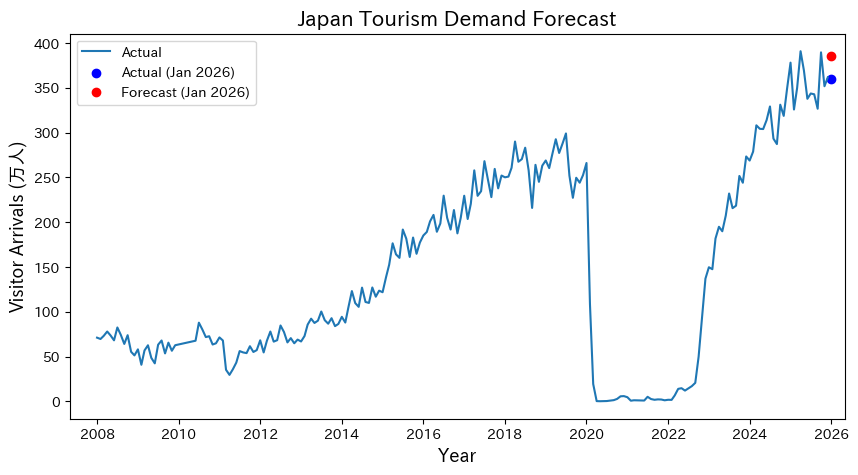

In [107]:
# visualization
plt.figure(figsize=(10, 5))

# 実測（〜2025年まで）
plt.plot(y, label="Actual")

# 2026年1月の実測（点で追加）
actual_date = pd.to_datetime(["2026-01-01"])
actual_value = [actual_2026_01.item()]

plt.scatter(
    actual_date,
    actual_value,
    label="Actual (Jan 2026)",
    color="blue"
)

# 2026年1月の予測（点で追加）
pred_date = pd.to_datetime(["2026-01-01"])
pred_value = [float(pred_2026_01)]

plt.scatter(
    pred_date,
    pred_value,
    label="Forecast (Jan 2026)",
    color="red"
)

plt.xlabel("Year", fontsize=13)
plt.ylabel("Visitor Arrivals (万人)", fontsize=13)

# 表示範囲
plt.xlim(pd.to_datetime("2007-05-01"), pd.to_datetime("2026-05-01"))

# 万人単位
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/10000:.0f}")
)

plt.legend()
plt.title("Japan Tourism Demand Forecast", fontsize=15)

plt.savefig(images_path + "tourism_demand_forecast2.png", dpi=300)

plt.show()

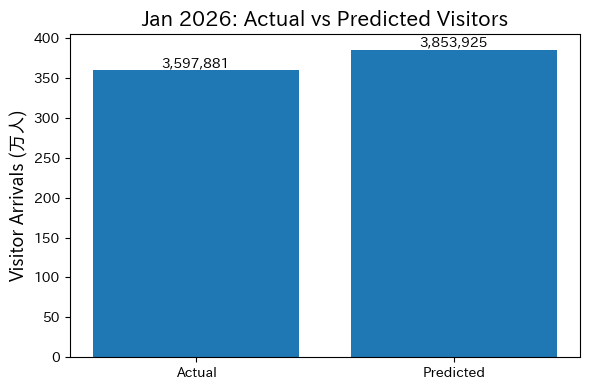

In [108]:
# 棒グラフ
plt.figure(figsize=(6, 4))

labels = ["Actual", "Predicted"]
values = [actual, pred]

plt.bar(labels, values)

plt.title("Jan 2026: Actual vs Predicted Visitors", fontsize=15)
plt.ylabel("Visitor Arrivals (万人)", fontsize=13)

# 数値を表示
for i, v in enumerate(values):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom")

# 万人単位で表示
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}')
)

plt.tight_layout()
plt.savefig(images_path + "tourism_demand_forecast3.png", dpi=300)

plt.show()